In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [4]:
df = pd.read_csv("/content/Superstore.csv", encoding="latin1")

# Display first five records
print(df.head())

# Display dataset information
print(df.info())

# Check missing values
print(df.isnull().sum())
print(df.columns)


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

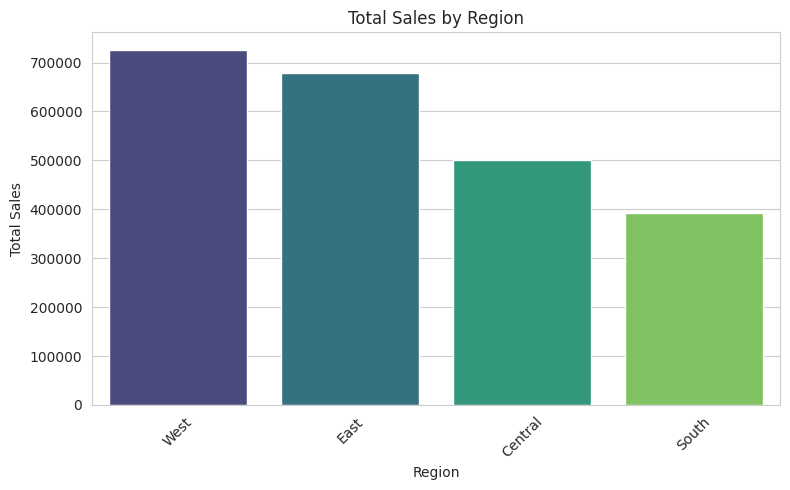

In [5]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    hue=region_sales.index,
    palette="viridis",
    legend=False
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


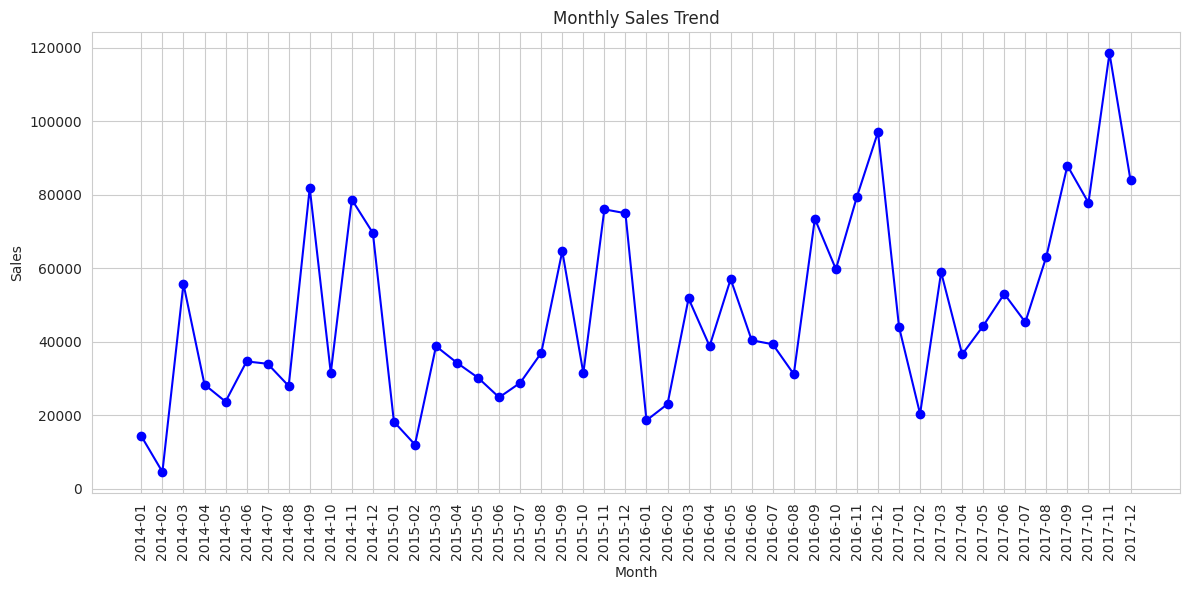

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

plt.figure(figsize=(12, 6))
plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o",
    color="blue"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()


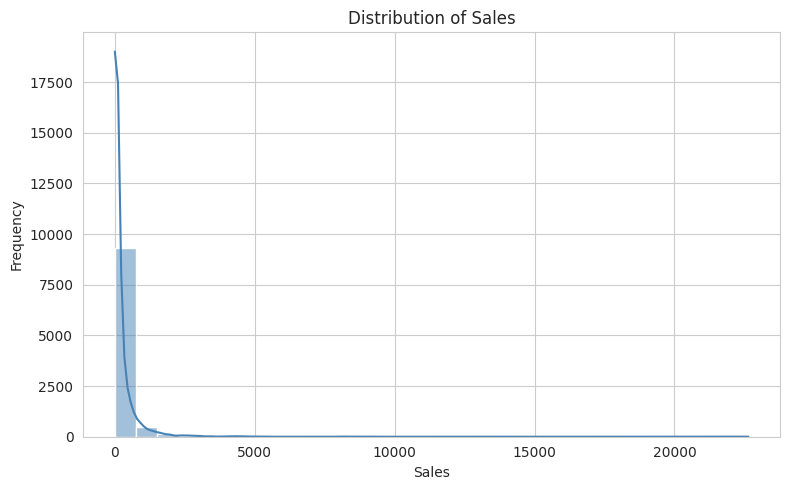

In [7]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Sales"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


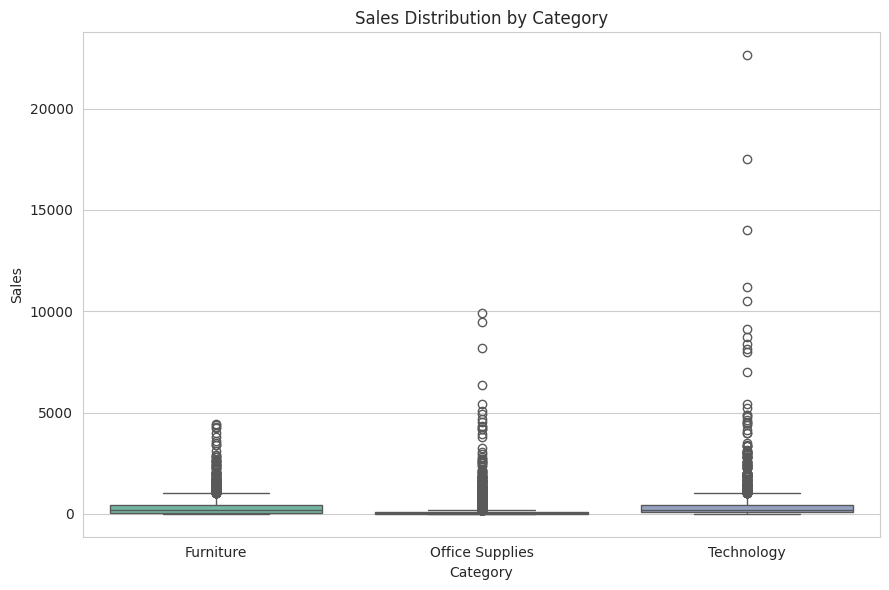

In [8]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Category",
    y="Sales",
    hue="Category",
    palette="Set2",
    legend=False
)

plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


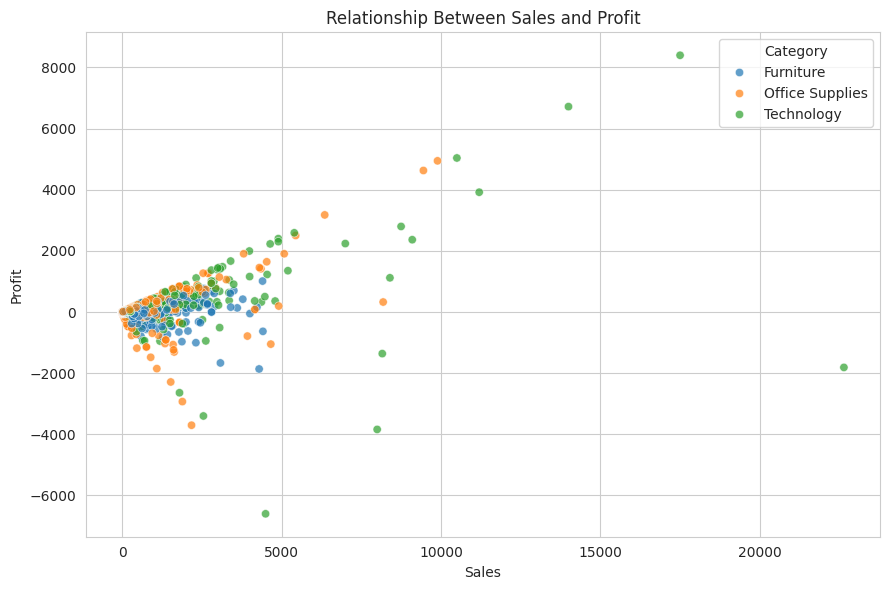

In [9]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Category",
    alpha=0.7
)

plt.title("Relationship Between Sales and Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.legend(title="Category")
plt.tight_layout()
plt.show()


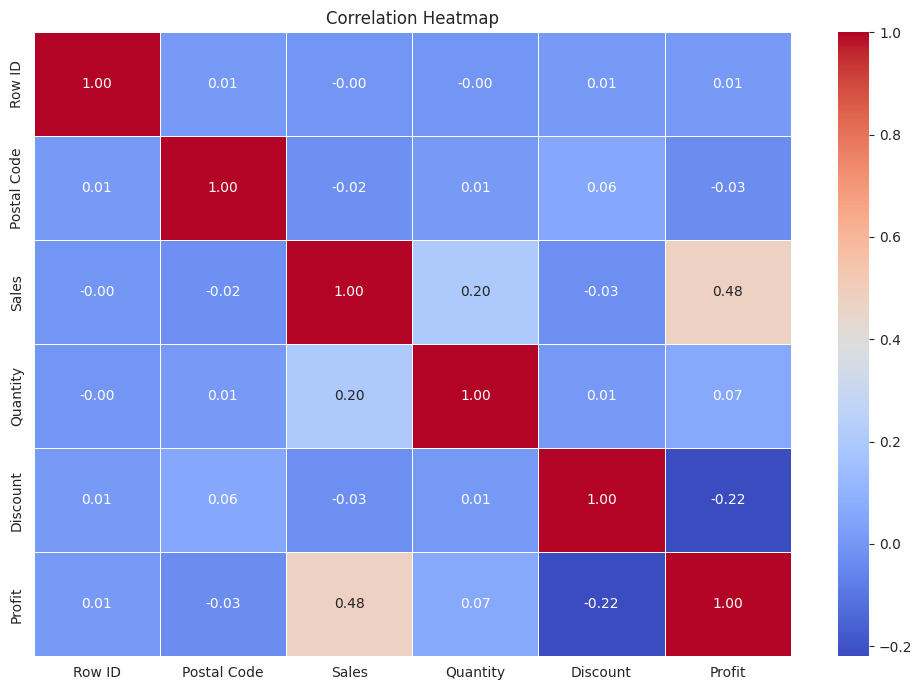

In [10]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


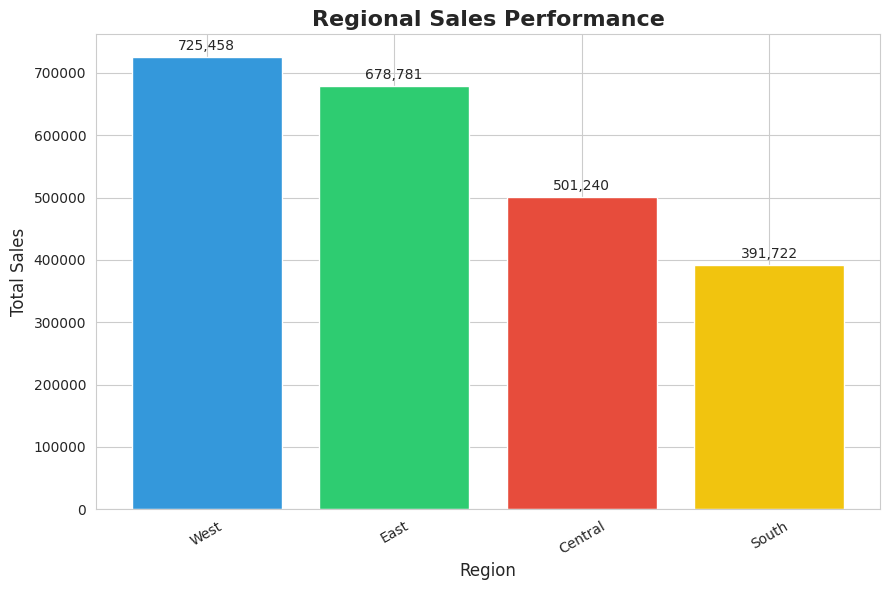

In [11]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    region_sales.index,
    region_sales.values,
    color=["#3498db", "#2ecc71", "#e74c3c", "#f1c40f"]
)

plt.title("Regional Sales Performance", fontsize=16, fontweight="bold")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f"{height:,.0f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
